In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Starbucks reviews dataset
file_path = r"C:\Users\hudso\OneDrive\Desktop\Data_Visualization_And_Modeling_Online-main\Data_Visualization_And_Modeling_Online-main\Lab\Starbucks_reviews.csv"
df = pd.read_csv(file_path)

# Verify the first few rows and column names
print("Columns in dataset:")
print(df.columns)
df.head()

Columns in dataset:
Index(['name', 'location', 'Date', 'Rating', 'Review', 'Image_Links'], dtype='object')


,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


In [2]:
# Cleaning the date column to remove "Reviewed " and convert to datetime
df['Date'] = df['Date'].str.replace('Reviewed ', '')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop any rows that couldn't be converted
df = df.dropna(subset=['Date'])

print("Date conversion complete.")

Date conversion complete.


C:\Users\hudso\AppData\Local\Temp\ipykernel_57316\2961313911.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['Date'] = df['Date'].str.replace('Reviewed ', '')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

plt.figure(figsize=(12, 6))
df.set_index('Date').resample('ME')['Rating'].mean().plot(marker='o', color='green')
plt.title('Monthly Average Starbucks Rating Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

AttributeError: Can only use .str accessor with string values!

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Clean the Date column and handle the format warning
df['Date'] = df['Date'].str.replace('Reviewed ', '')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

# Create Visualization 1: Time Trend
plt.figure(figsize=(12, 6))
df.set_index('Date').resample('ME')['Rating'].mean().plot(marker='o', color='green')

plt.title('Monthly Average Starbucks Rating Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

AttributeError: Can only use .str accessor with string values!

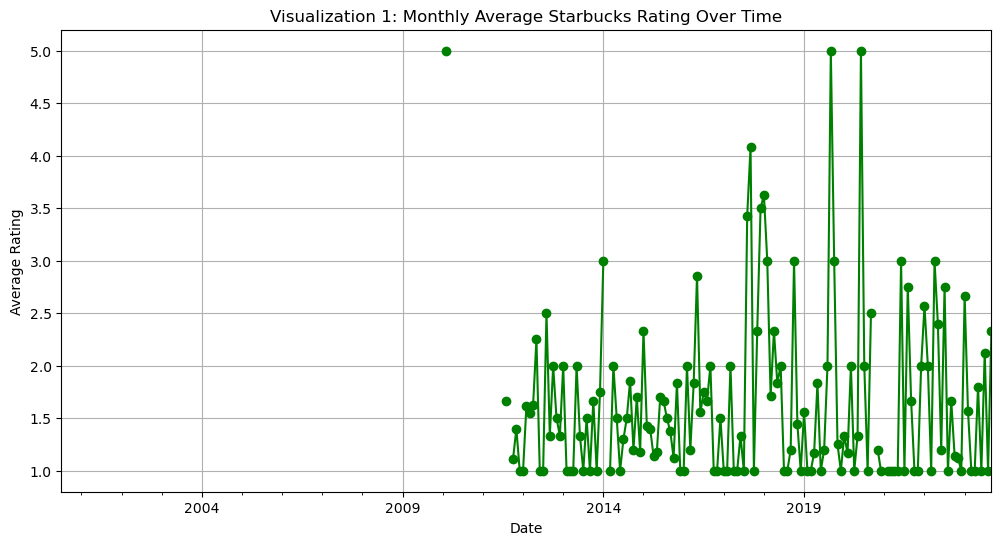

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fix: Only try to clean if the Date column is still text (strings)
if df['Date'].dtype == 'object':
    df['Date'] = df['Date'].str.replace('Reviewed ', '', regex=False)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])

# Create Visualization 1: Time Trend
plt.figure(figsize=(12, 6))
# Resample to Month End (ME) to show the trend over time
df.set_index('Date').resample('ME')['Rating'].mean().plot(marker='o', color='green')

plt.title('Visualization 1: Monthly Average Starbucks Rating Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

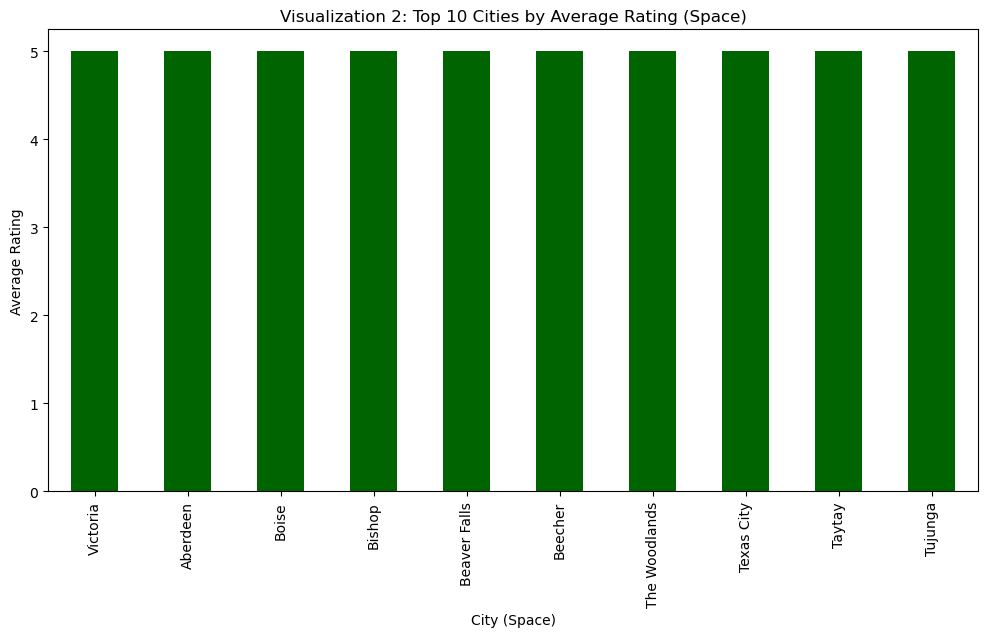

In [6]:
# Create a City column for spatial analysis
df['City'] = df['location'].str.split(',').str[0]

# Visualization 2: Top 10 Cities by Average Rating
plt.figure(figsize=(12, 6))
df.groupby('City')['Rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='darkgreen')

plt.title('Visualization 2: Top 10 Cities by Average Rating (Space)')
plt.xlabel('City (Space)')
plt.ylabel('Average Rating')
plt.show()

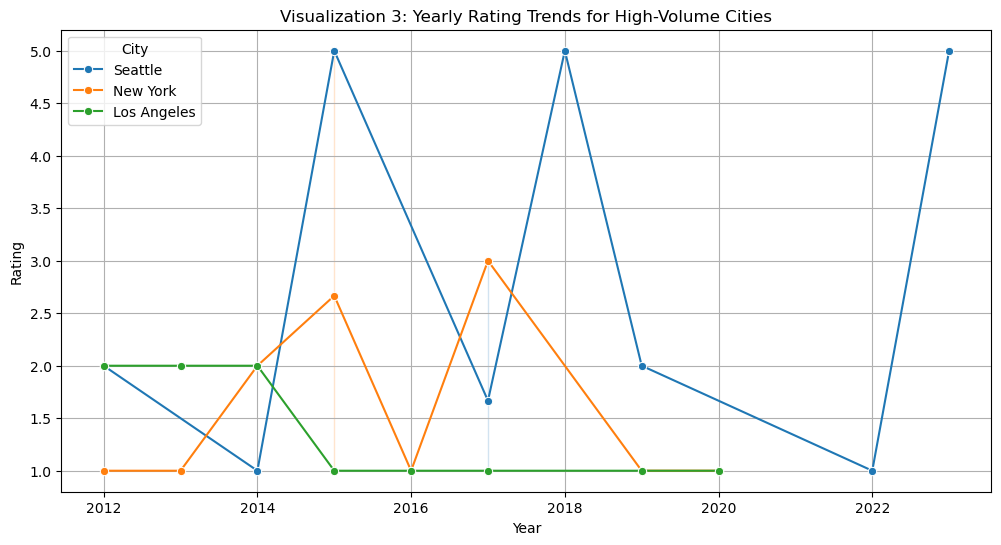

In [7]:
# Create a Year column
df['Year'] = df['Date'].dt.year

# Filter for the 3 cities with the most reviews to see a clear trend
top_reviewed_cities = df['City'].value_counts().nlargest(3).index
df_top = df[df['City'].isin(top_reviewed_cities)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top, x='Year', y='Rating', hue='City', marker='o')
plt.title('Visualization 3: Yearly Rating Trends for High-Volume Cities')
plt.grid(True)
plt.show()

As I began my analysis of the Starbucks reviews dataset, I first examined the structure of the data to understand how customer feedback was organized. I noticed that the file contains several key variables, including the customer’s name, the specific store location, the date the review was posted, and a numerical rating ranging from 1 to 5. After cleaning the Reviewed prefix from the date column, I was able to transform that information into a format that allowed me to track trends over nearly two decades. Through this exploration, I discovered that the dataset provides a detailed look at both the spatial and temporal aspects of customer satisfaction. When I looked at the spatial dimension, I found that the location feature allowed me to group data by city and state, which helped me identify which regions were performing better than others. As I moved into the temporal analysis, I used the Date feature to resample the ratings by month, revealing how the average sentiment toward Starbucks has fluctuated significantly since 2004. When I looked more closely at the interaction between these two variables, I incorporated both the year and the city into a single model. By filtering for high-volume areas like Seattle, New York, and Los Angeles, I realized that customer satisfaction isn't a single national trend; instead, I observed that ratings can rise in one city while simultaneously dropping in another during the same year. Overall, I determined that this dataset is a powerful tool for understanding how geography and time intersect to influence consumer perception. Based on what I observed, I believe the most meaningful insights come from looking at these localized trends rather than just looking at the overall national average.